# 04 — Corners & Cards Models

The goal model can't derive corners/cards, so these use XGBoost count regressors (Poisson objective) on the same rolling-form/rating features, then price over/under lines via `pl_predictor.models.market_models.price_over_under` — the same 'supply your own lambda' pattern penaltyblog documents for `create_dixon_coles_grid`.

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')

from pl_predictor.models import manifest

result = manifest.train_all()
print('Chosen scoreline model:', result['scoreline']['chosen_model'])
print('Corners:', result['corners']['metrics'], 'dispersion:', result['corners']['dispersion'])
print('Cards:  ', result['cards']['metrics'], 'dispersion:', result['cards']['dispersion'])

Training on 2660 matches, validating on 380 (held-out season).


  > Dixon-Coles RPS=0.2117  Bivariate-Poisson RPS=0.2117  (chosen: bivariate_poisson)


  > Corners MAE=2.66  Cards MAE=1.61
Chosen scoreline model: bivariate_poisson
Corners: {'mae': 2.6645188331604004, 'rmse': 3.310435677520408, 'mean_actual': 9.99736842105263, 'mean_predicted': 10.231605529785156} dispersion: 1.1367779111324987
Cards:   {'mae': 1.6097533702850342, 'rmse': 1.9923353551712146, 'mean_actual': 3.85, 'mean_predicted': 3.8418967723846436} dispersion: 1.1457318673672405


Dispersion (variance/mean) above ~1.2 means the count is overdispersed relative to a pure Poisson — `price_over_under` automatically switches to a negative binomial in that case.

## Corners feature importance

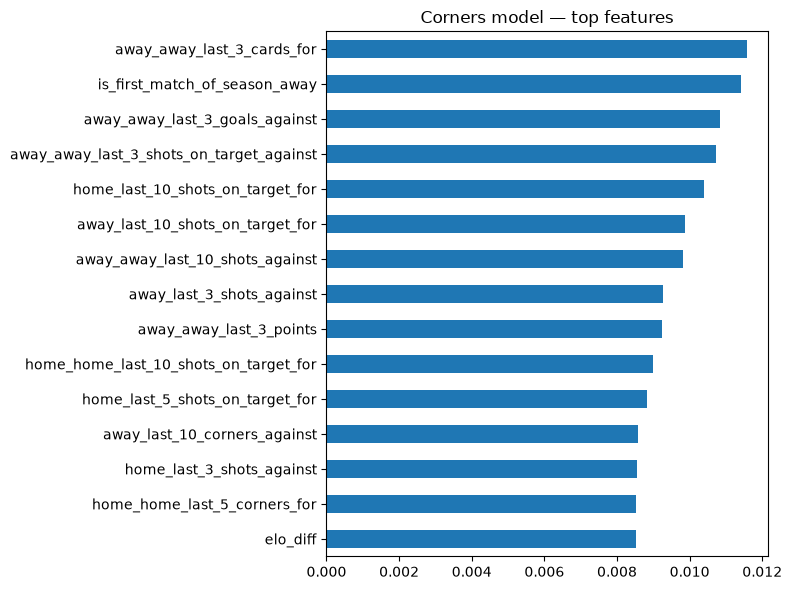

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from pl_predictor.models.manifest import load_models

models = load_models()
importance = pd.Series(models['corners'].feature_importances_, index=models['feature_cols'])
importance.sort_values().tail(15).plot(kind='barh', figsize=(8, 6), title='Corners model — top features')
plt.tight_layout(); plt.show()

## Example over/under pricing

See notebook 06 for real fixture predictions — this just illustrates `price_over_under` given an expected value.

In [3]:
from pl_predictor.models.market_models import price_over_under

price_over_under(lam=10.2, line=9.5, dispersion=result['corners']['dispersion'])

{'lambda': 10.2,
 'line': 9.5,
 'over': 0.5668290964267844,
 'under': 0.43317090357321564}